# 1. 分词器-Qwen3的分词器

In [24]:
from transformers import AutoTokenizer
from pathlib import Path
import json

model_dir = "/Volumes/AI/models/local/Qwen3-Embedding-0.6B"

tokenizer = AutoTokenizer.from_pretrained(model_dir, trust_remote_code=True)

print(tokenizer.unk_token)
print(tokenizer.eos_token)
print(tokenizer.bos_token)
print(tokenizer.pad_token)
print(tokenizer.sep_token)
print(tokenizer.cls_token)
print(tokenizer.mask_token)

print("*" * 100)
print(tokenizer.all_special_ids)

print("*" * 100)
print(tokenizer.all_special_tokens)

print("*" * 100)
print(tokenizer.get_added_vocab())

print("*" * 100)
config = json.loads((Path(model_dir) / "tokenizer_config.json").read_text())
print(config.get("additional_special_tokens", []))

print("*" * 100)
print("base vocab_size:", tokenizer.vocab_size)
print("total vocab_size:", len(tokenizer))


None
<|im_end|>
None
<|endoftext|>
None
None
None
****************************************************************************************************
[151645, 151643]
****************************************************************************************************
['<|im_end|>', '<|endoftext|>']
****************************************************************************************************
{'<|endoftext|>': 151643, '<|im_start|>': 151644, '<|im_end|>': 151645, '<|object_ref_start|>': 151646, '<|object_ref_end|>': 151647, '<|box_start|>': 151648, '<|box_end|>': 151649, '<|quad_start|>': 151650, '<|quad_end|>': 151651, '<|vision_start|>': 151652, '<|vision_end|>': 151653, '<|vision_pad|>': 151654, '<|image_pad|>': 151655, '<|video_pad|>': 151656, '<tool_call>': 151657, '</tool_call>': 151658, '<|fim_prefix|>': 151659, '<|fim_middle|>': 151660, '<|fim_suffix|>': 151661, '<|fim_pad|>': 151662, '<|repo_name|>': 151663, '<|file_sep|>': 151664, '<tool_response>': 151665, '</tool_resp

In [25]:
# 分词 
line = "<|im_start|>Qwen3 Embedding 模型系列是 Qwen 家族的最新专有模型，专门设计用于文本嵌入和排序任务。"
"基于 Qwen3 系列的密集基础模型，它提供了各种大小（0.6B、4B 和 8B）的全面文本嵌入和重排序模型。"
"该系列继承了其基础模型卓越的多语言能力、长文本理解和推理技能。Qwen3 Embedding 系列在多个文本嵌入和排序任务中取得了显著进步，"
"包括文本检索、代码检索、文本分类、文本聚类和双语文本挖掘。<|im_end|>"

tokens = tokenizer.encode(line, add_special_tokens=True)
print(tokens)
result = tokenizer(line)["input_ids"]  # 分词(数据集：transformers提供的规则：模型的输入，数据集)
print(result)
print("*"*80)
print("解码：", tokenizer.decode(result))

[151644, 48, 16948, 18, 37068, 6968, 6567, 44401, 24300, 100187, 20412, 1207, 16948, 41479, 114, 70769, 9370, 104027, 95411, 18830, 104949, 3837, 102093, 70500, 100751, 108704, 103767, 17254, 33108, 74661, 88802, 1773, 151643]
[151644, 48, 16948, 18, 37068, 6968, 6567, 44401, 24300, 100187, 20412, 1207, 16948, 41479, 114, 70769, 9370, 104027, 95411, 18830, 104949, 3837, 102093, 70500, 100751, 108704, 103767, 17254, 33108, 74661, 88802, 1773, 151643]
********************************************************************************
解码： <|im_start|>Qwen3 Embedding 模型系列是 Qwen 家族的最新专有模型，专门设计用于文本嵌入和排序任务。<|endoftext|>


# 2. 预训练的词嵌入-Qwen3的预训练的词嵌入

In [26]:
from transformers import AutoModel
model = AutoModel.from_pretrained(model_dir)
# print(model
print(model.embed_tokens)   # 词嵌入
print(model.embed_tokens.weight.shape)

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Embedding(151669, 1024)
torch.Size([151669, 1024])


In [27]:
# 把词转换为向量
text_1 = "训练"
text_2 = "训"

tokens_1 = tokenizer.encode(text_1)
tokens_2 = tokenizer.encode(text_2)

print(tokens_1)
print(tokens_2)


print(model.embed_tokens.weight[tokens_1[0]])   # 训练的词向量
print(model.embed_tokens.weight[tokens_2[0]]) 

[104034, 151643]
[99732, 151643]
tensor([ 0.0176, -0.0645,  0.0037,  ...,  0.0479, -0.0295, -0.0219],
       dtype=torch.bfloat16, grad_fn=<SelectBackward0>)
tensor([-0.0173, -0.0669,  0.0013,  ...,  0.0503, -0.0762, -0.0194],
       dtype=torch.bfloat16, grad_fn=<SelectBackward0>)


# 3. 准备数据集-HuggingFace提供的数据集框架datasets

In [28]:
from datasets import load_dataset  # 集成了json，csv等数据集文件的处理，而且批量处理

dataset = load_dataset(
    "csv",
    data_files={
        "train": "./train.csv",
        "valid": "./test.csv"
    }
)
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['label', 'content'],
        num_rows: 4000
    })
    valid: Dataset({
        features: ['label', 'content'],
        num_rows: 495
    })
})


In [29]:
dataset["train"][0]

{'label': '体育',
 'content': '中国“铁腰”与英超球队埃弗顿分道扬镳，闪电般转投谢联（本赛季成功升入英超），此事运作速度之快令人惊诧。针对李铁与埃弗顿“分手”的原因、与埃弗顿主帅莫耶斯矛盾以及铁子为何选择谢联，记者昨日采访了李铁的母亲王桂芹，李母道出了李铁与埃弗顿分开的真实原因。龙菲坚决让铁子走人记者在采访王桂芹时了解到，李铁离开埃弗顿主要是妻子龙菲建议。龙菲平时不太过问李铁的足球方面事宜，但是，因为李铁长时间不能在埃弗顿踢上球，龙菲也十分焦急。多次安慰李铁后，龙菲想这样下去也不是个办法，于是索性做出决定，让李铁离开埃弗顿，只要能踢上球，去哪支球队都行。但前提条件必须是英国的球队。王妈妈告诉记者：“媳妇龙菲一直在英国学习，这孩子特别懂事，一边学习，一边还要照顾女儿和李铁的日常生活。对于李铁与埃弗顿的前前后后，龙菲一直都了解内情，因此龙菲最后告诉李铁，就是埃弗顿再请我们，我们也不去了，只要能离开埃弗顿，去哪支球队踢球都行。”据悉，龙菲２００１年便在沈阳拿到了留学英国全额奖学金的录取通知书，而后，龙菲便一直在英国求学。红牌让李铁失去位置“拼命三郎”、“跑不死”、“体能王”，这些溢美之词都是称赞李铁的，不过，正是因为李铁防守时的动作过于凶狠，在英超的赛场上屡次领到红牌。过多的红牌让主帅莫耶斯逐渐对李铁失去了兴趣。对此，王妈妈向记者表示：“关于球队的相关事宜，我不太清楚。因为埃弗顿主教练莫耶斯一直都很器重李铁，因为莫耶斯的战术比较偏重防守。而在防守过程中，李铁也确实吃到过红牌，但是，我觉得教练组和俱乐部不能因为红牌的原因不让李铁上场吧。”许宏涛挽救李铁李铁成功转会埃弗顿的整个过程，国内足球著名的经纪人许宏涛功不可没。而李铁在埃弗顿后期四处碰壁的危难时刻，正是许宏涛的左右逢源，令李铁还能坚持在埃弗顿预备队踢球。后来，在埃弗顿摒弃李铁后，也正是许宏涛的人脉关系让李铁再次找到了位置。根据李铁与埃弗顿签订的合同，今年６月３０日，工作合同才到期。但是，考虑到李铁与俱乐部的关系日益紧张，许宏涛便提早联系了英超其他球队，重点便是当时的英甲球队谢联。由于许宏涛是谢联董事会的成员，多次与俱乐部沟通李铁的事宜后，俱乐部最终同意了李铁加盟谢联。对李铁加盟谢联的事情，王桂芹不愿多谈。她只是表示：“许宏涛一直在帮助李铁，特别是在英国，许宏涛非常熟悉那里的环境，李铁也非常信任

In [30]:
dataset["valid"][0]

{'label': '体育',
 'content': '届数比赛时间比赛地点参加国家和地区冠军亚军决赛成绩第一届1956-1957英国11美国丹麦6：1第二届1959-1960费城（美国）14美国英国5：2第三届1962-1963威尔明顿（美国）11美国英国4：3第四届1965-1966惠灵顿（新西兰）17日本美国5：2第五届1968-1969东京（日本）19日本印尼6：1第六届1971-1972东京（日本）17日本印尼6：1第七届1974-1975雅加达（印尼）14印尼日本5：2第八届1977-1978奥克兰（新西兰）16日本印尼5：2第九届1980-1981东京（日本）15日本印尼4：3第十届1983-1984吉隆坡（马来西亚）23中国印尼5：0第十一届1986雅加达（印尼）34中国印尼3：2第十二届1988吉隆坡（马来西亚）31中国韩国5：0第十三届1990东京（日本）42中国韩国3：2第十四届1992吉隆坡（马来西亚）44中国韩国3：2第十五届1994雅加达（印尼）44印尼中国3：2第十六届1996香港（中国）50印尼中国4：1第十七届1998香港（中国）50中国印尼5：0第十八届2000吉隆坡（马来西亚）50中国印尼5：0第十九届2002广州（中国）50中国韩国3：1第二十届2004雅加达（印尼）50中国韩国3：1第二十一届2006东京（日本）50中国荷兰3：0'}

# 4. 构建批次数据集

- 批次数据集:
    - 分词
    - 转换成编号
    - 对齐（截断，补齐）

In [31]:
classes = ["体育", "军事", "健康", "教育", "汽车"]
classes_id = {l: i for i, l in enumerate(classes)}   # 把文本标签转换为id。
print(classes_id)

{'体育': 0, '军事': 1, '健康': 2, '教育': 3, '汽车': 4}


In [32]:
# 分词的处理器
max_length = 1024
def token_func(sample):
    # 把sample分词。然后返回
    # 1. 对样本分析
    tokens = tokenizer(
        sample["content"],          # 被分词的文本
        max_length=max_length,
        truncation=True,            # 超过就截断
        padding=False               # 暂时不补齐
    )
    # 标签分词
    tokens["labels"] = [classes_id[l] for l in sample["label"]]  # 原来的标签是label，这里是批次标签labels
    return tokens

tokenized_dataset = dataset.map(token_func, batched=True)        # 转换为批次数据集

In [33]:
print(tokenized_dataset)

DatasetDict({
    train: Dataset({
        features: ['label', 'content', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 4000
    })
    valid: Dataset({
        features: ['label', 'content', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 495
    })
})


In [34]:
# print(tokenized_dataset["train"][0])
# 去掉多余的字段
tokenized_dataset.set_format(type="torch", columns=["input_ids", "labels"])
# print(tokenized_dataset["train"][0])

In [35]:
from torch.utils.data import DataLoader
# 调整器
from transformers import DataCollatorWithPadding # 对齐使用

# 构建一个调整器
collator = DataCollatorWithPadding(
    tokenizer= tokenizer,   # 调用分词器中padding的token，而且利用tokenizer的pad函数直接对齐
    padding="max_length",   # 对齐的方式，使用max_length参数指定的长度对齐 
    max_length=max_length,
    return_tensors="pt"
)

loader = DataLoader(tokenized_dataset["train"], batch_size=64, shuffle=True, collate_fn=collator) 


In [48]:
# for d in loader:
#     print(d)
#     break

# 5. 词嵌入的运算

- 词嵌入：
    - 使用预训练
    - 直接使用，在使用中训练

In [36]:
from torch import nn
embedding = nn.Embedding(
    num_embeddings=len(tokenizer.get_vocab()),   # tokenizer.vocab_size,   # 等于词袋的大小  len(tokenizer.get_vocab())
    embedding_dim=512,   # 词向量的长度
    padding_idx=0
)
print(embedding.weight.shape)

torch.Size([151669, 512])


In [37]:
loader = DataLoader(tokenized_dataset["train"], batch_size=64, shuffle=True, collate_fn=collator) 
for d in loader:
    x = d["input_ids"]
    print(x.shape)
    y = embedding(x)   # 词嵌入运算
    print(y.shape)
    # print(y)
    break

torch.Size([64, 1024])
torch.Size([64, 1024, 512])


- 代码说明：
    - 把词编号转换为词向量，其实就是查找词嵌入表。
    - 返回的就是词对应的词向量，这个向量如果是训练的，就表示词的特征向量。

# 6. 使用词嵌入构建分类器

In [16]:
from torch import nn
from transformers import Qwen3Model   # 词嵌入训练模型
class TextClassifier(nn.Module):
    def __init__(self, num_classes=5, hidden_dim=64, dropout=0.5):
        """
            num_classes :分类的了类别数：决定输出的向量的长度
            hidden_dim: 分类器的矩阵的行数
        """
        super(TextClassifier, self).__init__()
        # 定义层数
        # 第一层：词嵌入（充分利用预训练的词的特征）
        self.model = Qwen3Model.from_pretrained(model_dir)   # 加载预训练模型
        self.embedding = self.model.embed_tokens             # 使用预训练模型
        # self.embedding = nn.Embedding(len(tokenizer.get_vocab()), 1024)   # 未训练的词嵌入（效果会很差）
        # 词袋大小
        self.vocab_size, self.embedding_dim = self.embedding.weight.shape
        
        # 第二层：分类
        self.fc1 = nn.Linear(self.embedding_dim, hidden_dim)  # 词向量的长度作为分类器的输入长度
        self.fc2 = nn.Linear(hidden_dim, num_classes)

        # 激活函数
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        
        # 降维的方式
        # self.pooling = "mean"   # max, sum
        

    def forward(self, x):
        """
            输入的x[batch_size, seq_length] # seq_length句子的长度
        """
        # 运算
        embedded = self.embedding(x)  # 向量化的词向量 【batch_size, seq_length, embedding_dim】

        # 降维（全部采用mean降维）
        mask = (x != 0 ).float().unsqueeze(-1)   # 增加维度，便于与embedded进行矩阵运算（三维）
        pooled =(embedded * mask).sum(dim=1) / (mask.sum(dim=1) + 1e-8)  # 第二维求和（二维） : 求均值池化
        """
        if self.pooling == 'mean':
            # 平均池化（忽略padding的影响）
            mask = (x != 0).float().unsqueeze(-1)  # [B, L, 1]
            pooled = (embedded * mask).sum(dim=1) / (mask.sum(dim=1) + 1e-8)
        elif self.pooling == 'max':
            # 最大池化
            embedded = embedded.masked_fill((x == 0).unsqueeze(-1), -1e9)
            pooled = embedded.max(dim=1)[0]
        else:  # sum
            pooled = embedded.sum(dim=1)
        """

        # 第一个分类器（激活运算）
        hidden = self.fc1(pooled) 
        hidden = self.relu(hidden)   # 激活运算
        hidden = self.dropout(hidden)  # 随机丢弃
        # 第二个分类器
        hidden = self.fc2(hidden)
        return hidden   # [batch_size, num_classes]

In [ ]:
## 改写

In [ ]:
import torch
from torch import nn
from transformers import Qwen3Model, AutoTokenizer


class TextClassifier(nn.Module):
    def __init__(
        self,
        model_dir="/Volumes/AI/models/local/Qwen3-Embedding-0.6B",
        num_classes=5,
        hidden_dim=64,
        dropout=0.5,
        freeze_embedding=True,
    ):
        """
        基于 Qwen3 预训练词嵌入的文本分类模型。

        参数:
            model_dir: 本地 Qwen3-Embedding 模型路径
            num_classes: 分类类别数，决定最终输出维度
            hidden_dim: 中间隐藏层维度
            dropout: Dropout 随机丢弃比例，用于缓解过拟合
            freeze_embedding: 是否冻结预训练词嵌入参数
        """
        super().__init__()

        # 加载分词器，用来获取 pad_token_id
        # 后面做 mean pooling 时，需要用 pad_token_id 忽略 padding 部分
        tokenizer = AutoTokenizer.from_pretrained(
            model_dir,
            trust_remote_code=True
        )

        # Qwen3 的 padding token id
        # 注意不能直接写 0，因为 Qwen3 的 pad_token_id 不是 0
        self.pad_token_id = tokenizer.pad_token_id

        # 加载 Qwen3 模型
        # 这里主要是为了取出其中已经训练好的词嵌入层 embed_tokens
        qwen = Qwen3Model.from_pretrained(model_dir)

        # 取出预训练词嵌入层
        # 输入 token id 后，可以得到对应的词向量
        self.embedding = qwen.embed_tokens

        # 删除完整的 Qwen3 模型对象
        # 因为这里只使用 embedding，不使用完整 Transformer 结构
        del qwen

        # 设置 embedding 的 padding_idx
        # 这个 id 对应 padding token
        self.embedding.padding_idx = self.pad_token_id

        # 如果 freeze_embedding=True，则不训练词嵌入层
        # 只训练后面的分类器部分
        if freeze_embedding:
            self.embedding.weight.requires_grad = False

        # 获取词表大小和词向量维度
        # Qwen3-Embedding-0.6B 的 embedding_dim 通常是 1024
        self.vocab_size, self.embedding_dim = self.embedding.weight.shape

        # 第一层全连接层
        # 输入维度是词向量维度，输出维度是 hidden_dim
        self.fc1 = nn.Linear(self.embedding_dim, hidden_dim)

        # 第二层全连接层
        # 输出维度是分类类别数
        self.fc2 = nn.Linear(hidden_dim, num_classes)

        # 激活函数
        self.relu = nn.ReLU()

        # Dropout 层
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        """
        前向传播。

        参数:
            x: token id 张量，形状为 [batch_size, seq_length]
               dtype 必须是 torch.long

        返回:
            logits: 分类结果，形状为 [batch_size, num_classes]
        """

        # 将 token id 转换成词向量
        # embedded 形状: [batch_size, seq_length, embedding_dim]
        embedded = self.embedding(x)

        # 构造 mask，用于忽略 padding token
        # x != self.pad_token_id 的位置为 1，padding 位置为 0
        # unsqueeze(-1) 后形状变为 [batch_size, seq_length, 1]
        mask = (x != self.pad_token_id).float().unsqueeze(-1)

        # 对所有非 padding 的 token 向量做平均池化
        # embedded * mask 会把 padding 位置的词向量置为 0
        # sum(dim=1) 对 seq_length 维度求和
        # mask.sum(dim=1) 是每个句子的有效 token 数
        pooled = (embedded * mask).sum(dim=1) / (mask.sum(dim=1) + 1e-8)

        # 进入第一层分类器
        hidden = self.fc1(pooled)

        # 非线性激活
        hidden = self.relu(hidden)

        # Dropout 随机丢弃部分神经元
        hidden = self.dropout(hidden)

        # 输出分类 logits
        logits = self.fc2(hidden)

        return logits


In [39]:
classifer = TextClassifier(num_classes=5, hidden_dim=64, dropout=0.2)

loader = DataLoader(tokenized_dataset["train"], batch_size=64, shuffle=True, collate_fn=collator) 
for d in loader:
    outputs = classifer(d["input_ids"])
    print(outputs.shape)
    break

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

torch.Size([64, 5])


# 7. 模型评估-训练前

In [40]:
from sklearn.metrics import classification_report,accuracy_score

def eval_model(model, val_loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for d in val_loader:
            outputs = model(d["input_ids"])

            if hasattr(outputs, "logits"):
                outputs = outputs.logits

            _, predicted = torch.max(outputs, dim=1)

            labels = d["labels"]
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return correct / total

# 8. 训练实现

In [ ]:
# import torch
# from torch import nn
# from torch import optim


# def train_model(model, train_loader, val_loader, epoches , lr = 0.001):

#     loss_f = nn.CrossEntropyLoss()                      #损失函数
#     optimizer = optim.Adam(model.parameters(),lr=lr)    #优化器 

#     #记录两个数据
#     train_loss      = []            #训练的损失值
#     val_accuracies  = []            #评估集的准确度

#     for e in range(epoches):
#         model.train()
#         total_loss = 0.0
#         for d in train_loader:

#             #梯度清零
#             optimizer.zero_grad()

#             #预测
#             outputs = model(d["input_ids"])

#             #计算损失值
#             loss = loss_f(outputs,d["labels"])

#             #自动求道
#             loss.backward()

#             #梯度更新
#             optimizer.step()

#         #评估
#         avg_loss = total_loss / len(train_loader)       #批次平均average，mean
#         train_loss.append(avg_loss)

#         val_accu = eval_model(model,val_loader)
#         val_accuracies.append(val_accu)

#         if (e+1)%10 == 0:
#             print(f"轮数：{e+1:03d}/{epoches},损失值：{avg_loss:10.6f},准确度：{val_accu:.4f}")

#     return total_loss,val_accuracies


In [41]:
import torch
from torch import nn
from torch import optim


def train_model(model, train_loader, val_loader, epoches, lr=0.001):
    loss_f = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_loss = []
    val_accuracies = []

    for e in range(epoches):
        model.train()
        total_loss = 0.0

        for d in train_loader:
            optimizer.zero_grad()

            outputs = model(d["input_ids"])

            loss = loss_f(outputs, d["labels"])

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_loss.append(avg_loss)

        val_accu = eval_model(model, val_loader)
        val_accuracies.append(val_accu)

        if (e + 1) % 10 == 0:
            print(
                f"轮数：{e + 1:03d}/{epoches}, "
                f"损失值：{avg_loss:10.6f}, "
                f"准确度：{val_accu:.4f}"
            )

    print("*"*80)

    return train_loss, val_accuracies


# 9. 运行训练

In [42]:
train_loader = DataLoader(
    tokenized_dataset["train"],
    batch_size=64,
    shuffle=True,
    collate_fn=collator
)

valid_loader = DataLoader(
    tokenized_dataset["valid"],
    batch_size=64,
    shuffle=False,
    collate_fn=collator
)

classifier = TextClassifier(num_classes=5, hidden_dim=64, dropout=0.2)

train_losses, valid_accuracies = train_model(
    classifier,
    train_loader,
    valid_loader,
    100,
    0.001
)


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

轮数：010/100, 损失值：  0.276016, 准确度：0.9616


KeyboardInterrupt: 

In [ ]:
torch.save(classifer,"model.pt")

In [ ]:
nodel = torch.load("model.pt",weights_only=False)

# 10. 可视化训练数据

当前使用字体： Hiragino Sans GB


NameError: name 'train_losses' is not defined

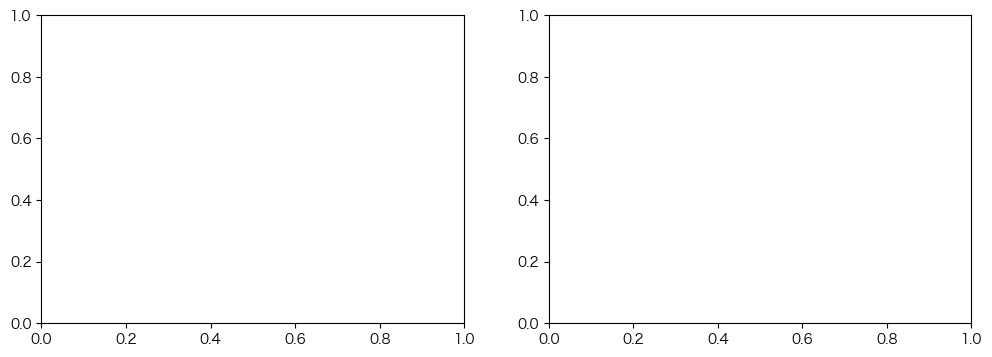

In [21]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 自动选择可用中文字体
candidate_fonts = [
    "Microsoft YaHei",   # Windows
    "SimHei",            # Windows
    "PingFang SC",       # macOS
    "Hiragino Sans GB",  # macOS
    "Arial Unicode MS",
    "Noto Sans CJK SC"
]

installed_fonts = {f.name for f in font_manager.fontManager.ttflist}

for font in candidate_fonts:
    if font in installed_fonts:
        plt.rcParams["font.sans-serif"] = [font]
        print("当前使用字体：", font)
        break

plt.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses)
axes[0].set_title("训练损失值")
axes[0].set_xlabel("轮数")
axes[0].set_ylabel("损失")
axes[0].grid(True)

axes[1].plot(valid_accuracies)
axes[1].set_title("评估精度")
axes[1].set_xlabel("轮数")
axes[1].set_ylabel("准确率")
axes[1].grid(True)

plt.tight_layout()
plt.show()



# 11. 评估-分类报告，混淆矩阵

In [22]:
# 测试集准确率
test_accuracy = evaluate_model(classifer, valid_loader)
print(f"测试集准确率: {test_accuracy:.4f}")

# 详细分类报告
classifer.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in valid_loader:
        outputs = classifer(batch["input_ids"])
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch["labels"].cpu().numpy())

print("\n分类报告:")
print(classification_report(all_labels, all_preds, target_names=['体育', '军事', '健康', '教育', '汽车']))

NameError: name 'evaluate_model' is not defined

# 12. 推理